<a href="https://colab.research.google.com/github/EdiOne07/DeepLearning-Experiments/blob/main/OutputLayerModification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Based on the previously trained model, now we want to modify the output layer and analyze the impact it has on our results

# Dependencies and Libraries

In [11]:
%pip install torchvision --index-url https://download.pytorch.org/whl/cu121
%pip install matplotlib numpy scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cu121


In [12]:
#!curl -O https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

#!unzip -q kagglecatsanddogs_5340.zip

In [13]:
import torch
import torchvision
import torch.nn as nn
import matplotlib.pyplot as plt
from typing import List, Tuple
from tqdm import tqdm

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print(f"Using device: {device}")

Using device: cuda


# CNN Architecture

In [14]:
## Understanding the architecture of the model: Separable Convolution and Residual Connections
class SeparableConv2d(nn.Module):
    def __init__(
        self,
        in_ch: int,
        out_ch: int,
        kernel_size: int = 3,
        padding: int = 1,
    ):
        super().__init__()

        # Depthwise: one filter bank per input channel (no cross-channel mixing)
        self.depthwise = nn.Conv2d(
            in_ch,
            in_ch,
            kernel_size=kernel_size,
            padding=padding,
            groups=in_ch, # No mixing of channels, each channel is convolved separately
            bias=False,
        )

        # Pointwise: 1x1 conv to mix channels and set output channels
        self.pointwise = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=1,
            bias=False,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


class ResidualSeparableConv2dBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()

        self.block = nn.Sequential(
            nn.ReLU(),
            SeparableConv2d(in_ch=in_ch, out_ch=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),

            nn.ReLU(),
            SeparableConv2d(in_ch=out_ch, out_ch=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),

            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # Project residual to match both spatial size and channels
        self.proj_res = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=1,
            stride=2,
            padding=0,
            bias=False,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x) + self.proj_res(x)


class CatsAndDogsCNN(nn.Module):
    def __init__(self, num_classes: int = 2, in_channels: int = 3):
        super().__init__()

        # Entry block
        self.entry_block = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Residual blocks for channel progression 128 -> 256 -> 512 -> 728
        self.blocks = nn.Sequential(
            ResidualSeparableConv2dBlock(in_ch=128, out_ch=256),
            ResidualSeparableConv2dBlock(in_ch=256, out_ch=512),
            ResidualSeparableConv2dBlock(in_ch=512, out_ch=728),
        )

        out_units = 1 if num_classes == 2 else num_classes

        # Final layers
        self.final_layers = nn.Sequential(
            SeparableConv2d(in_ch=728, out_ch=1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(1024, out_units), # logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # No scaling here because it is done by ToTensor() transform

        x = self.entry_block(x)
        x = self.blocks(x)
        x = self.final_layers(x)
        return x

# Loading the previously trained model

In [15]:
model = CatsAndDogsCNN(num_classes=2).to(device)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.to(device)
model.eval()

CatsAndDogsCNN(
  (entry_block): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (blocks): Sequential(
    (0): ResidualSeparableConv2dBlock(
      (block): Sequential(
        (0): ReLU()
        (1): SeparableConv2d(
          (depthwise): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=128, bias=False)
          (pointwise): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU()
        (4): SeparableConv2d(
          (depthwise): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
          (pointwise): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (5): BatchNorm2d(256, eps=1e-05, momentum=

In [16]:
output_layer=model.final_layers[-1]
num_features=output_layer.in_features
new_output_layer=nn.Linear(num_features,1)
model.final_layers[-1]=new_output_layer
model.to(device)

CatsAndDogsCNN(
  (entry_block): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (blocks): Sequential(
    (0): ResidualSeparableConv2dBlock(
      (block): Sequential(
        (0): ReLU()
        (1): SeparableConv2d(
          (depthwise): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=128, bias=False)
          (pointwise): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU()
        (4): SeparableConv2d(
          (depthwise): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
          (pointwise): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (5): BatchNorm2d(256, eps=1e-05, momentum=

In [17]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

def load_from_directory(
    root_dir: str,
    batch_size: int = 32,
    val_split: float = 0.2,
    train_transforms: transforms.Compose = None,
    val_transforms: transforms.Compose = None,
):
    # Load the dataset twice to handle different transforms
    train_full_dataset = datasets.ImageFolder(root=root_dir, transform=train_transforms)
    val_full_dataset = datasets.ImageFolder(root=root_dir, transform=val_transforms)

    # Calculate exact sizes for 80/20 split
    total_size = len(train_full_dataset)
    print(total_size)
    validation_size = int(val_split * total_size)
    train_size = total_size - validation_size

    # Randomly generate indices
    generator = torch.Generator().manual_seed(42)
    indices = torch.randperm(total_size, generator=generator).tolist()

    # Slice indices into Train and Val
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    # Create Subsets
    train_dataset = Subset(train_full_dataset, train_indices)
    validation_dataset = Subset(val_full_dataset, val_indices)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)


    return train_loader, validation_loader, train_full_dataset.classes

# Basic data transformation
basic_transform = transforms.Compose([
    transforms.Resize((180, 180)),
    transforms.ToTensor(),
])

train_loader, validation_loader, class_names = load_from_directory(
    "./PetImages",
    train_transforms=basic_transform,
    val_transforms=basic_transform,
)

print(f"Classes: {class_names}")
print(f"Number of batches in train loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(validation_loader)}")

23410
Classes: ['Cat', 'Dog']
Number of batches in train loader: 586
Number of batches in validation loader: 147


In [18]:
import os

def filter_corrupted_images(root_dir: str):
    num_skipped = 0
    for folder_name in ("Cat", "Dog"):
        folder_path = os.path.join(root_dir, folder_name)
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                fobj = open(fpath, "rb")
                is_jfif = b"JFIF" in fobj.peek(10)
            finally:
                fobj.close()

            if not is_jfif:
                num_skipped += 1
                # Delete corrupted image
                os.remove(fpath)

    print(f"Deleted {num_skipped} images.")

filter_corrupted_images("./PetImages")

Deleted 0 images.


In [19]:
data_augmentation_transforms = transforms.Compose([
    transforms.Resize((180, 180)),
    transforms.RandomHorizontalFlip(), # Randomly flip images horizontally
    transforms.RandomRotation(10), # 10 degrees rotation
    transforms.ToTensor(),
])

# Loading again with the new data augmentation transforms
train_loader, validation_loader, class_names = load_from_directory(
    "./PetImages",
    train_transforms=data_augmentation_transforms,
    val_transforms=basic_transform,
)

23410


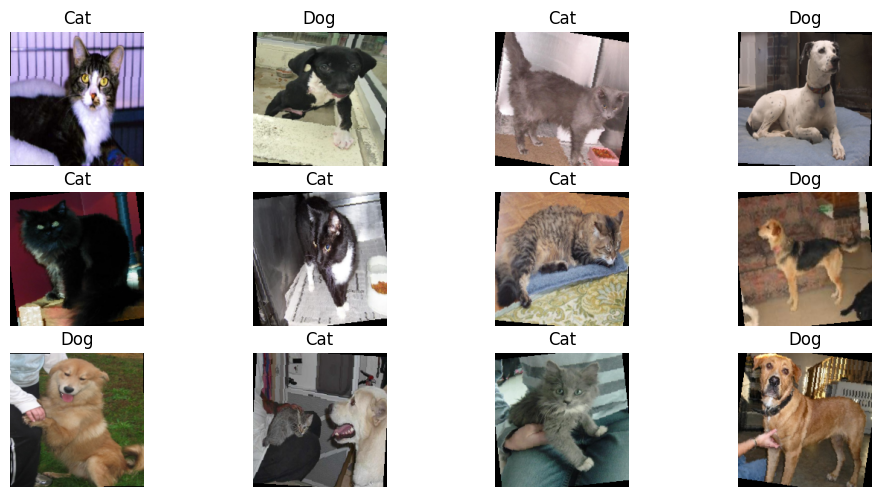

In [20]:
def visualize_batch(loader: DataLoader, class_names: list) -> None:
    images, labels = next(iter(loader))
    images = images.numpy().transpose((0, 2, 3, 1))

    plt.figure(figsize=(12, 8))
    for i in range(12):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

visualize_batch(train_loader, class_names)

In [21]:
def plot_loss(train_losses: list, val_losses: list) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend() # This enables the labels
    plt.show()

def plot_accuracy(train_accuracies: list, val_accuracies: list) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend() # Added this to show the legend
    plt.show()

# Training the model

In [22]:
EPOCHS = 25
LR = 1e-4

loss_fn = nn.BCEWithLogitsLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(f"Loss function: {loss_fn}")
print(f"Optimizer: {optimizer}")

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [23]:
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> Tuple[float, float]:
    model.train()
    total_loss = 0
    total_accuracy = 0

    for images, labels in tqdm(dataloader):
        images: torch.Tensor = images.to(device)
        labels: torch.Tensor = labels.to(device)

        # Forward pass
        outputs: torch.Tensor = model(images)
        loss: torch.Tensor = loss_fn(outputs.squeeze(), labels.float())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Evaluate accuracy
        if outputs.shape[1] == 1:
            # Squeeze to add a dimension
            preds = (torch.sigmoid(outputs.squeeze()) >= 0.5).long()
            total_accuracy += (preds == labels).sum().item()
        else:
            _, preds = torch.max(outputs, 1)
            total_accuracy += (preds == labels).sum().item()

        total_loss += loss.item() * images.size(0)

    avg_accuracy = total_accuracy / len(dataloader.dataset)
    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss, avg_accuracy


def validate_model(
    model: nn.Module,
    val_dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
) -> Tuple[float, float]:
    model.eval()
    total_loss = 0
    total_accuracy = 0

    with torch.inference_mode():
        for images, labels in tqdm(val_dataloader):
            images: torch.Tensor = images.to(device)
            labels: torch.Tensor = labels.to(device)

            outputs: torch.Tensor = model(images)
            loss: torch.Tensor = loss_fn(outputs.squeeze(), labels.float())

            # Evaluate accuracy
            if outputs.shape[1] == 1:
                # Squeeze to add a dimension
                preds = (torch.sigmoid(outputs.squeeze()) >= 0.5).long()
                total_accuracy += (preds == labels).sum().item()
            else:
                _, preds = torch.max(outputs, 1)
                total_accuracy += (preds == labels).sum().item()

            total_loss += loss.item() * images.size(0)

    avg_accuracy = total_accuracy / len(val_dataloader.dataset)
    avg_loss = total_loss / len(val_dataloader.dataset)
    return avg_loss, avg_accuracy


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int = 25,
) -> Tuple[List[float], List[float], List[float], List[float]]:
    # Track the losses
    train_losses = []
    val_losses = []

    # Track the accuracy
    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')

    for epoch in tqdm(range(epochs)):
        print("\nTraining pass:")
        train_loss, train_accuracy = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        print("\nValidation pass:")
        val_loss, val_accuracy = validate_model(model, validation_loader, loss_fn, device)

        # Track the accuracies
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # Track the losses
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

        # Model Checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Save the model weights
            torch.save(model.state_dict(), "best_model.pth")
            print("New best validation loss! Model saved to 'best_model.pth'")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [24]:
train_loader, validation_loader, class_names = load_from_directory(
    "./PetImages",
    train_transforms=data_augmentation_transforms,
    val_transforms=basic_transform,
    batch_size=128
)

train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
)

23410


  0%|          | 0/25 [00:00<?, ?it/s]


Training pass:



100%|██████████| 147/147 [04:20<00:00,  1.77s/it]



Validation pass:


...

Epoch 24/25 - Train Loss: 0.0411 - Val Loss: 0.1753

Training pass:



100%|██████████| 147/147 [04:22<00:00,  1.79s/it]



Validation pass:



100%|██████████| 25/25 [2:01:14<00:00, 290.98s/it]

Epoch 25/25 - Train Loss: 0.0358 - Val Loss: 0.1913
